# Prediction of Alzheimer's

Alzheimer's Disease is a progressive neurological disorder that affects memory, thinking, and behavior. It is the most common cause of dementia, primarily affecting older adults. Early detection and diagnosis are crucial for managing the disease and improving patient outcomes. In this project, we aim to build a predictive model to assist in the early diagnosis of Alzheimer's Disease using machine learning techniques.

## Data Preprocessing And Visualization

### Load the Dataset

In [1]:
library(tidyverse) # metapackage of all tidyverse packages

library(data.table)  
library(dplyr)       

#directory
setwd("/kaggle/input/alzheimers-disease-dataset")
data <- fread("./alzheimers_disease_data.csv")

setwd("/kaggle/working")

# View basic structure
head(data)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘data.table’




The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year




The following objects are masked from ‘package:dplyr’:

    between, first, last




The following object is masked from ‘package:purrr’:

    transpose




PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,⋯,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
4751,73,0,0,2,22.92775,0,13.297218,6.3271125,1.3472143,⋯,0,0,1.72588346,0,0,0,1,0,0,XXXConfid
4752,89,0,0,0,26.82768,0,4.542524,7.6198845,0.5187671,⋯,0,0,2.59242413,0,0,0,0,1,0,XXXConfid
4753,73,0,3,1,17.79588,0,19.555085,7.8449878,1.8263347,⋯,0,0,7.11954774,0,1,0,1,0,0,XXXConfid
4754,74,1,0,1,33.80082,1,12.209266,8.4280014,7.4356041,⋯,0,1,6.48122586,0,0,0,0,0,0,XXXConfid
4755,89,0,0,0,20.71697,0,18.454356,6.3104607,0.7954975,⋯,0,0,0.01469122,0,0,1,1,0,0,XXXConfid
4756,86,1,1,1,30.62689,0,4.140144,0.2110616,1.5849220,⋯,0,0,9.01568628,1,0,0,0,0,0,XXXConfid


### Handle Missing Values

In [2]:
cat_cols <- names(data)[sapply(data, is.character)]
print(cat_cols)

[1] "DoctorInCharge"


#### Drop "DoctorInCharge" and "PatientID"

In [3]:
data <- select(data, -c(PatientID, DoctorInCharge))
head(data)

Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,⋯,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
<int>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>
73,0,0,2,22.92775,0,13.297218,6.3271125,1.3472143,9.025679,⋯,6.518877,0,0,1.72588346,0,0,0,1,0,0
89,0,0,0,26.82768,0,4.542524,7.6198845,0.5187671,7.151293,⋯,7.118696,0,0,2.59242413,0,0,0,0,1,0
73,0,3,1,17.79588,0,19.555085,7.8449878,1.8263347,9.673574,⋯,5.895077,0,0,7.11954774,0,1,0,1,0,0
74,1,0,1,33.80082,1,12.209266,8.4280014,7.4356041,8.392554,⋯,8.965106,0,1,6.48122586,0,0,0,0,0,0
89,0,0,0,20.71697,0,18.454356,6.3104607,0.7954975,5.597238,⋯,6.045039,0,0,0.01469122,0,0,1,1,0,0
86,1,1,1,30.62689,0,4.140144,0.2110616,1.5849220,7.261953,⋯,5.510144,0,0,9.01568628,1,0,0,0,0,0


#### Convert Categorical Variables to Factors and One-Hot Encode

In [4]:
library(caret)

cat_cols <- names(data)[sapply(data, is.character)]

# Convert categorical variables to factors
for (col in cat_cols) {
  data[[col]] <- as.factor(data[[col]])
}

# Apply one-hot encoding
dummies <- dummyVars(" ~ .", data = data)
data_df <- predict(dummies, newdata = data)
data_df <- as.data.frame(data_df)

Loading required package: lattice




Attaching package: ‘caret’




The following object is masked from ‘package:purrr’:

    lift




The following object is masked from ‘package:httr’:

    progress




------------------------------------------------------------------------

### Initial Data Exploation Summary :

-   The dataset contains a total of 2,149 observations.

-   All values in the dataset are non-null and numerical.

-   There are no duplicate records.

-   After removing the `DoctorInCharge` and `PatientID` columns, the dataset consists of 33 features.

------------------------------------------------------------------------

### Visualization

In [5]:
# Identify numerical columns: Columns with more than 10 unique values are considered numerical
numerical_cols <- names(data_df)[sapply(data_df, function(col) length(unique(col)) > 10)]

# Identify categorical columns: Columns that are not numerical and not 'Alzheimer'
categorical_cols <- setdiff(names(data_df), c(numerical_cols, "Alzheimer"))

# Print the identified columns
cat("Numerical Columns : \n" , numerical_cols)
cat("\n\nCatagorical Columns : \n", categorical_cols)

Numerical Columns : 
 Age BMI AlcoholConsumption PhysicalActivity DietQuality SleepQuality SystolicBP DiastolicBP CholesterolTotal CholesterolLDL CholesterolHDL CholesterolTriglycerides MMSE FunctionalAssessment ADL



Catagorical Columns : 
 Gender Ethnicity EducationLevel Smoking FamilyHistoryAlzheimers CardiovascularDisease Diabetes Depression HeadInjury Hypertension MemoryComplaints BehavioralProblems Confusion Disorientation PersonalityChanges DifficultyCompletingTasks Forgetfulness Diagnosis

#### Distribution of Numerical Features

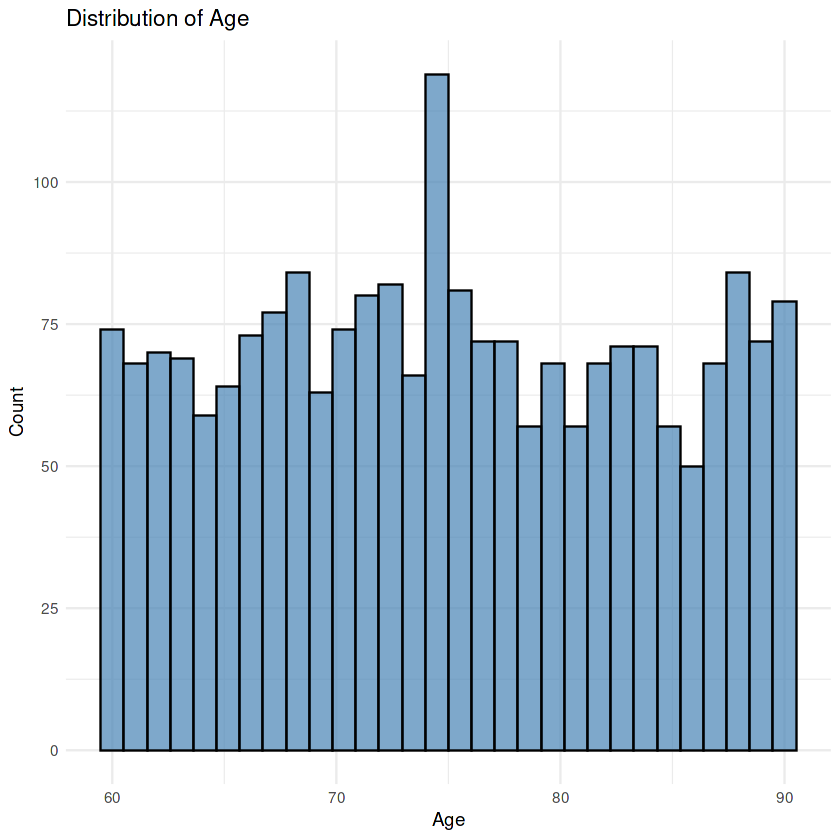

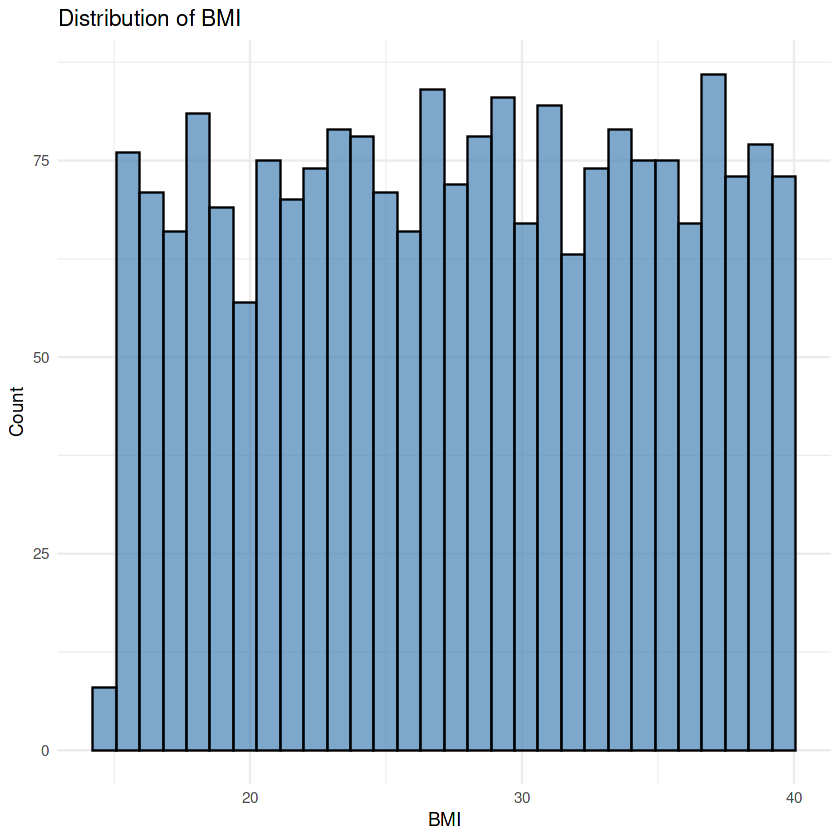

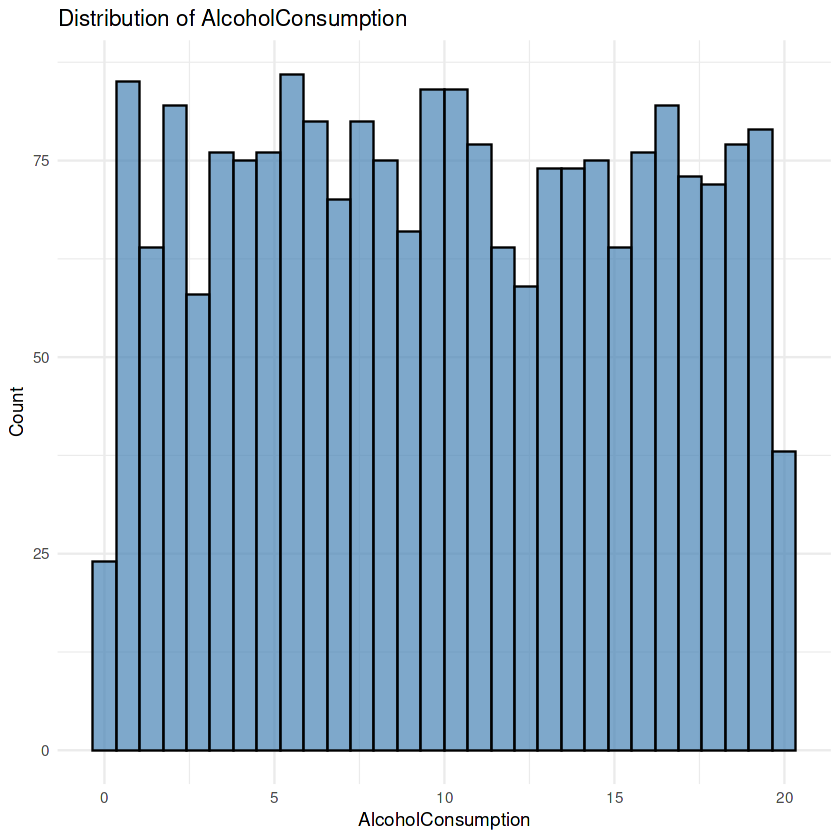

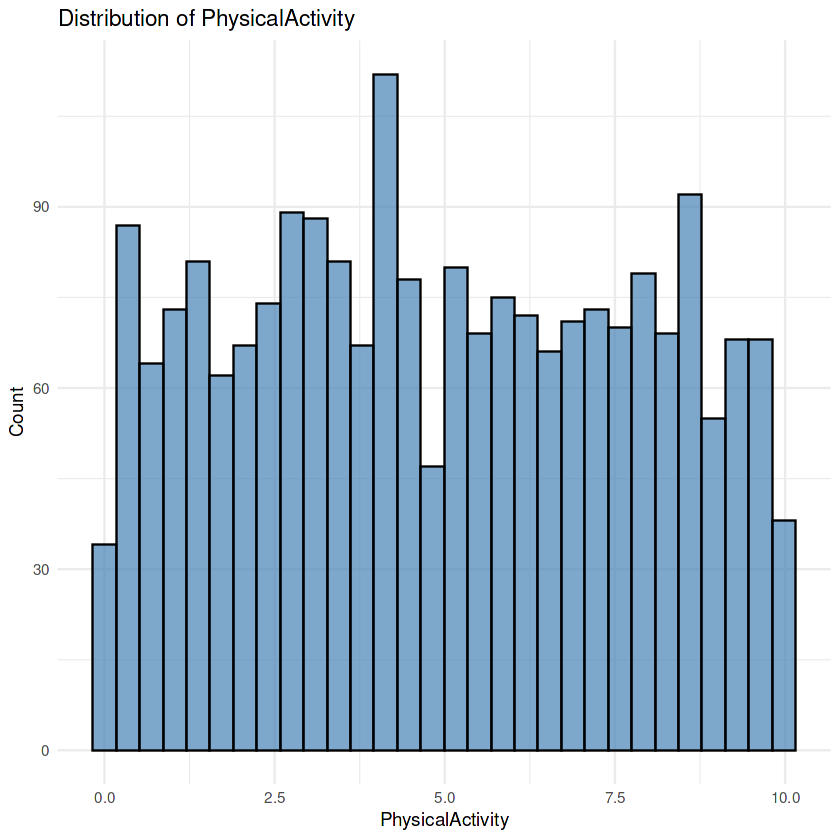

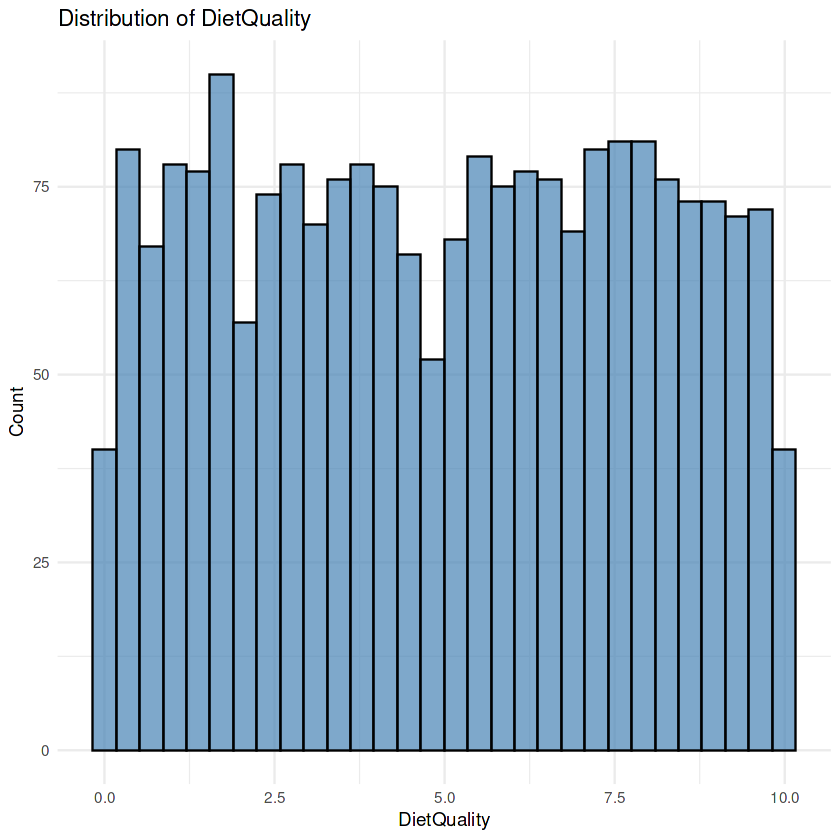

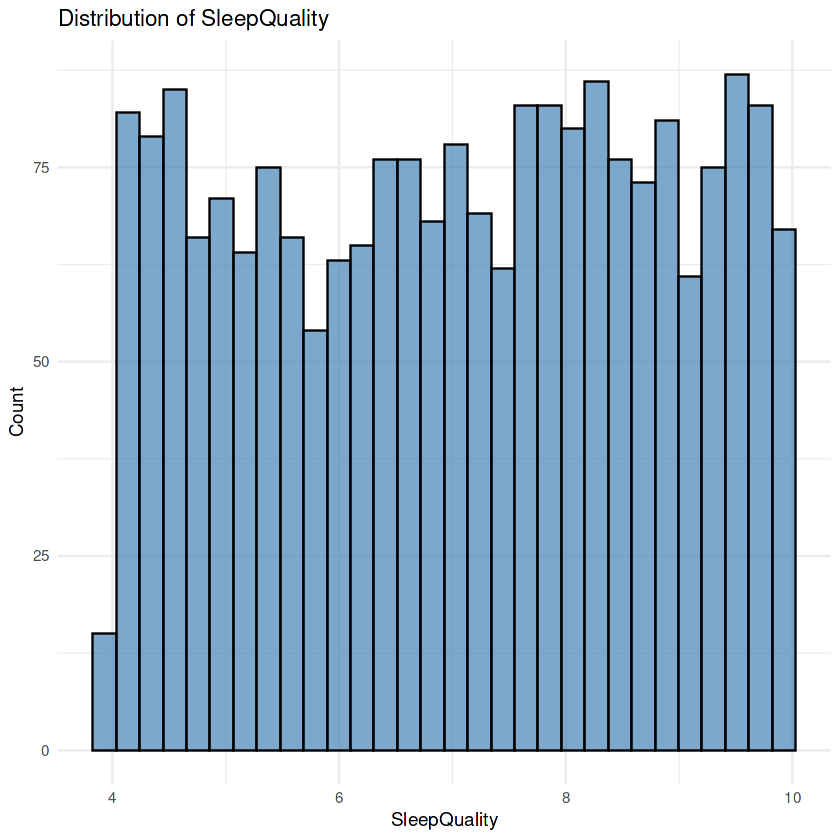

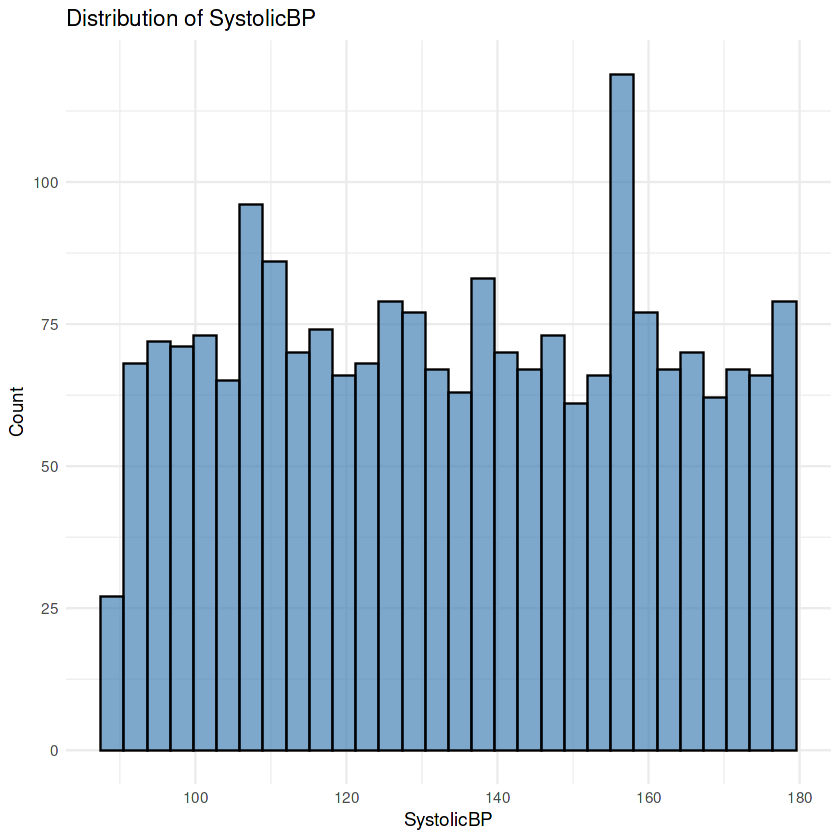

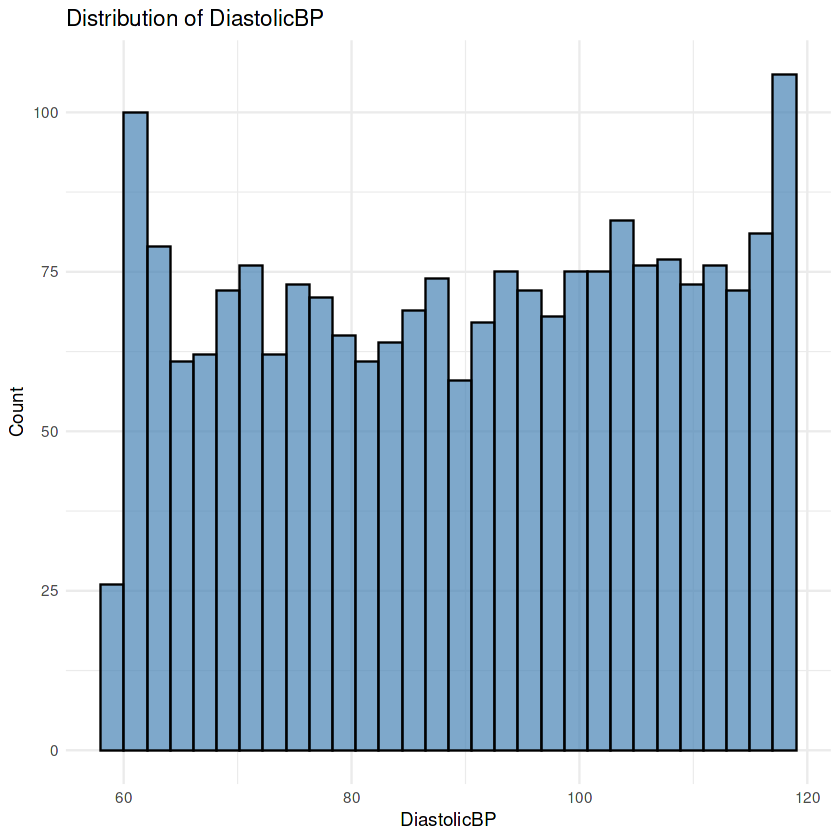

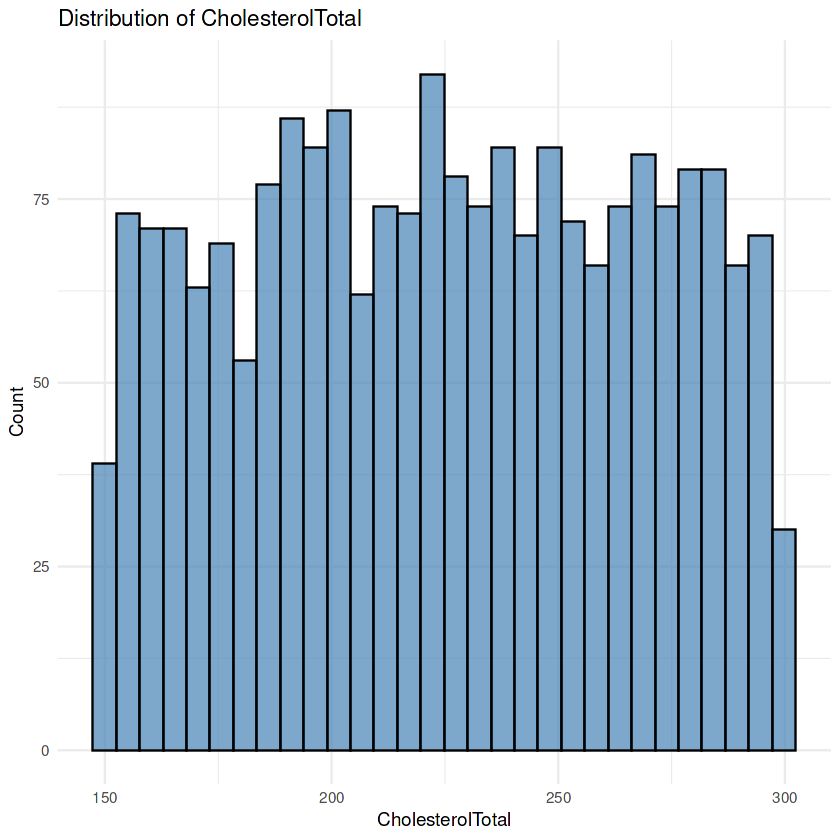

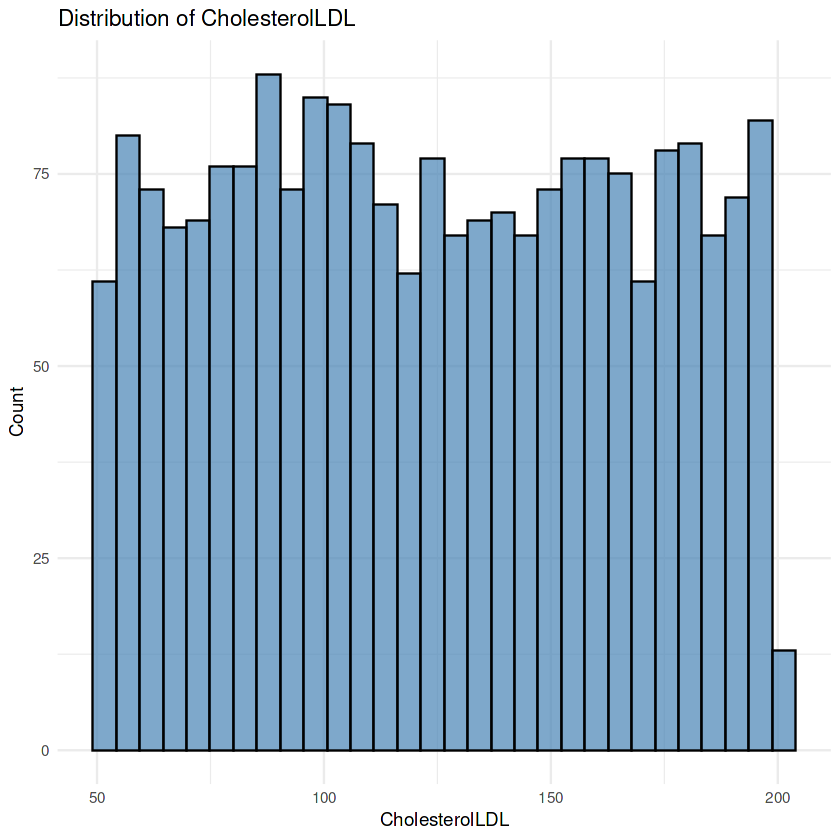

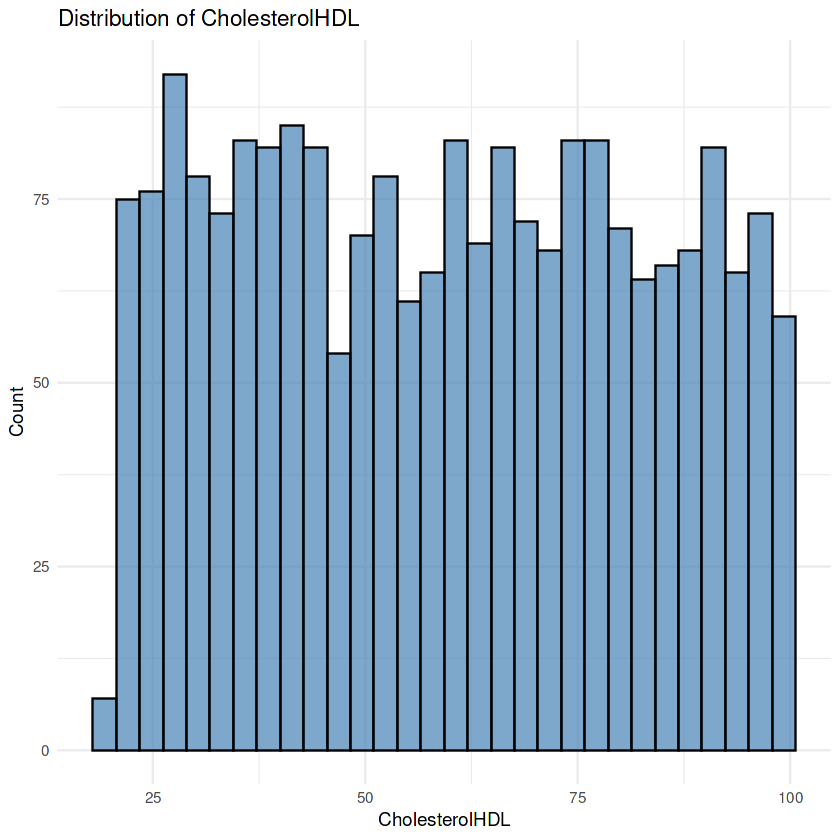

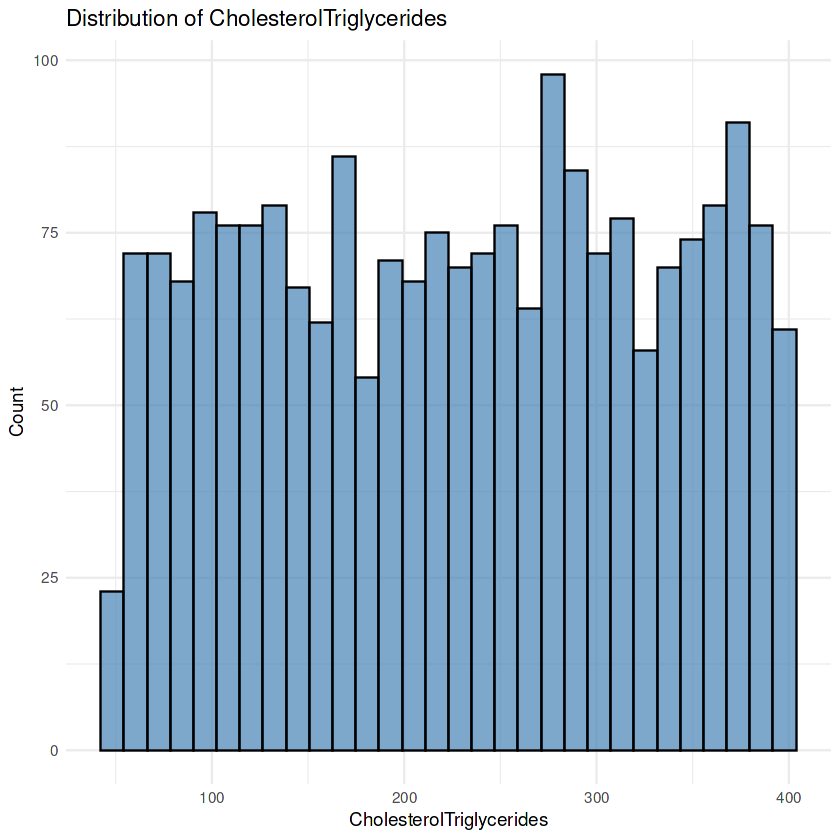

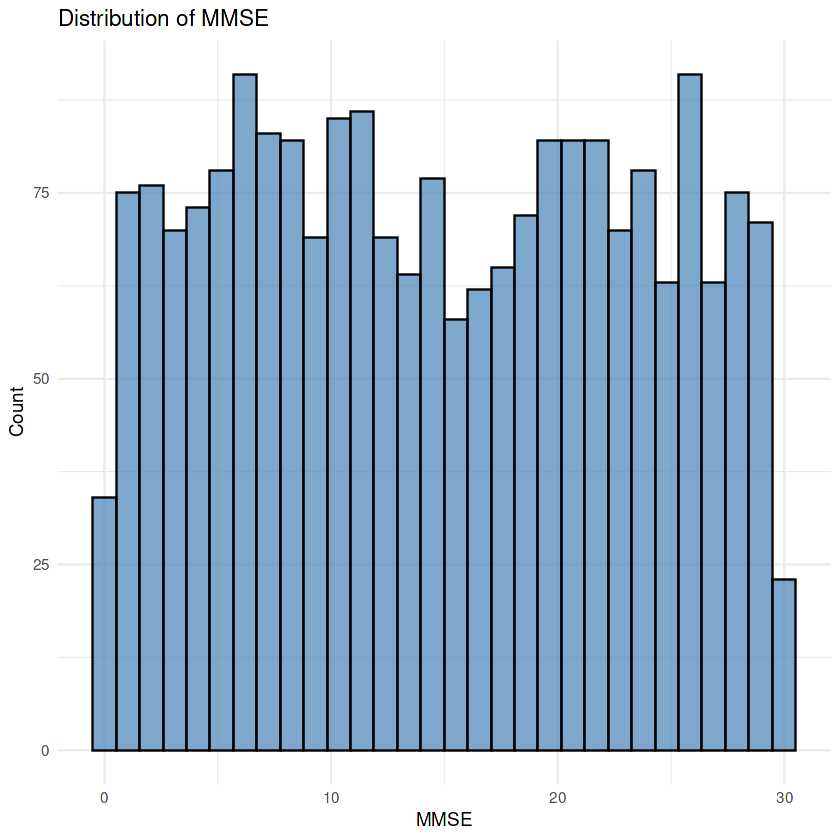

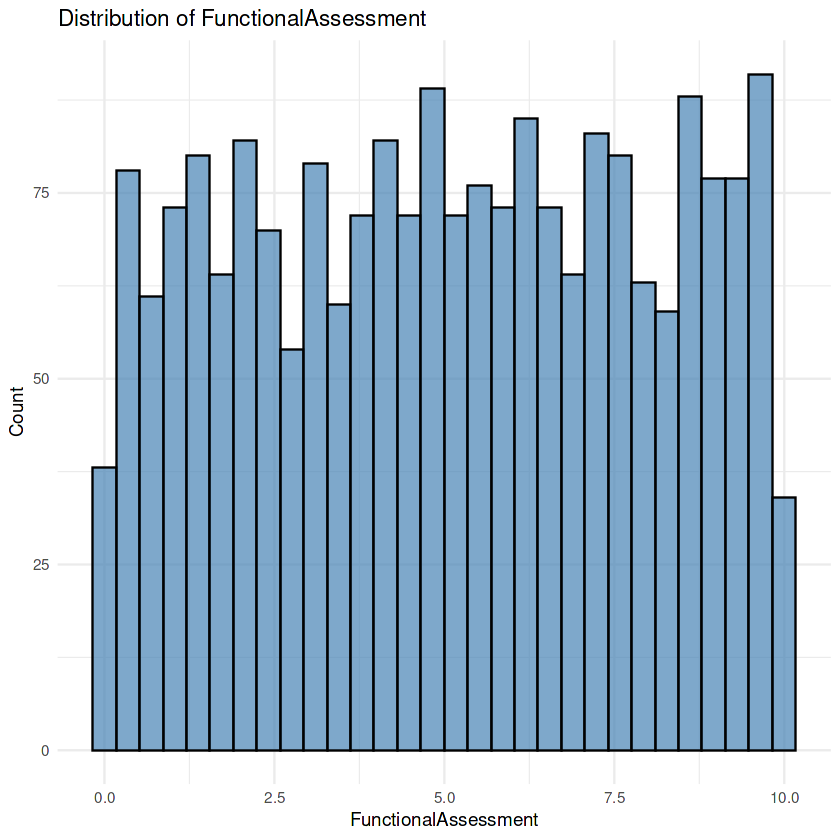

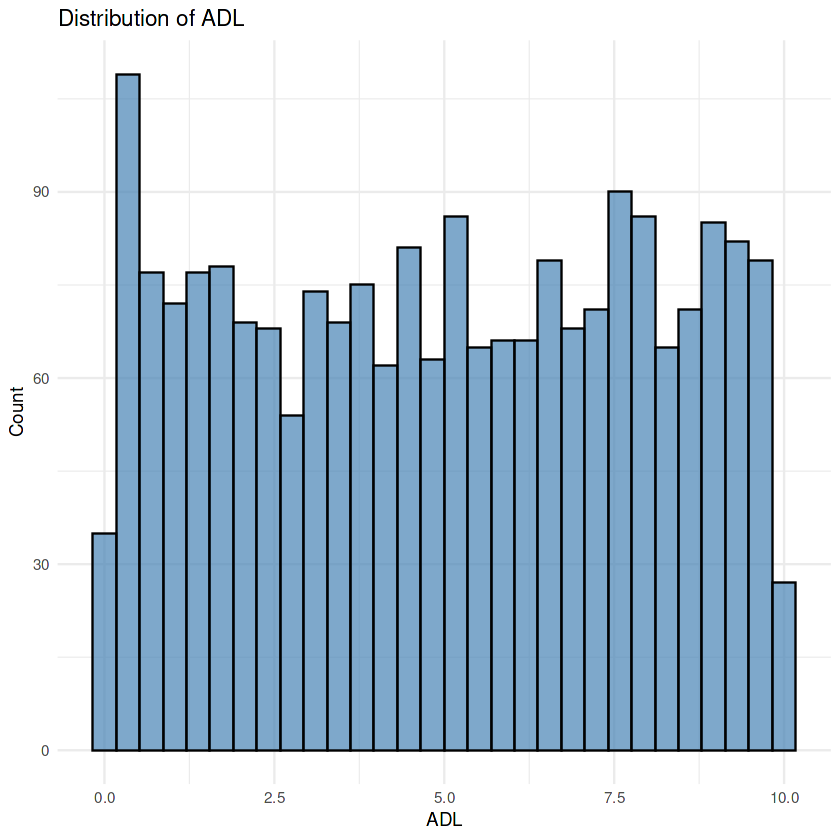

In [6]:
library(ggplot2)

# Plot histograms for numerical variables
for (col in numerical_cols) {
  print(
    ggplot(data_df, aes(x = get(col))) +
      geom_histogram(bins = 30, fill = "steelblue", color = "black", alpha = 0.7) +
      labs(title = paste("Distribution of", col), x = col, y = "Count") +
      theme_minimal()
  )
}

------------------------------------------------------------------------

### Observations from Visualization of Numerical Features

-   Most of the columns show a fairly uniform distribution.
-   The `MMSE` (Mini-Mental State Examination) scores appear to follow a bimodal distribution, indicating two distinct groups within the data.

------------------------------------------------------------------------

#### Distribution of Categorical Features

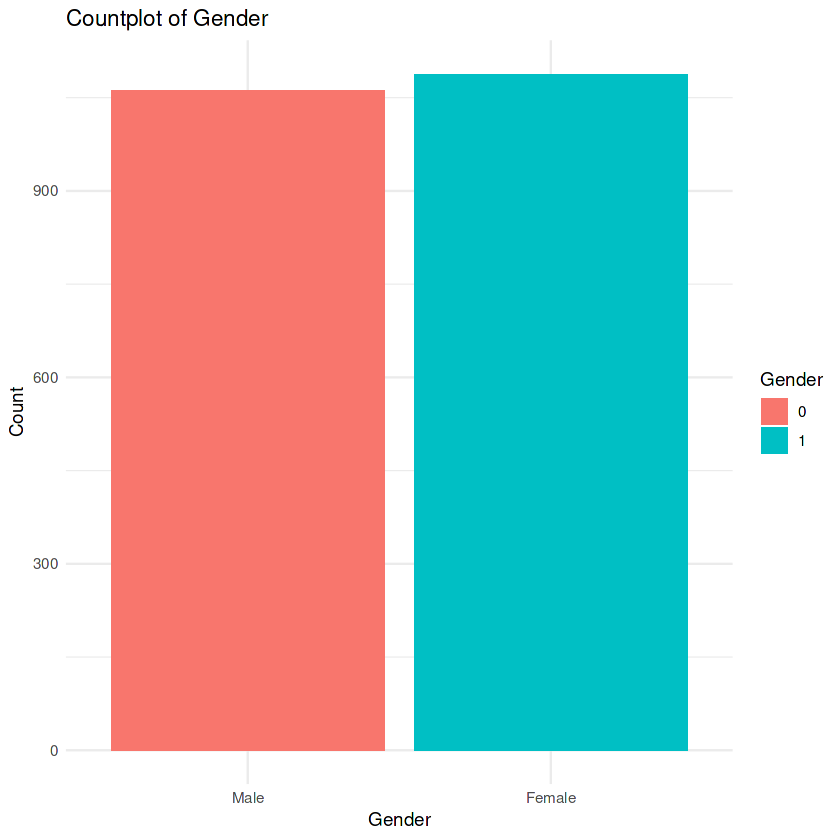

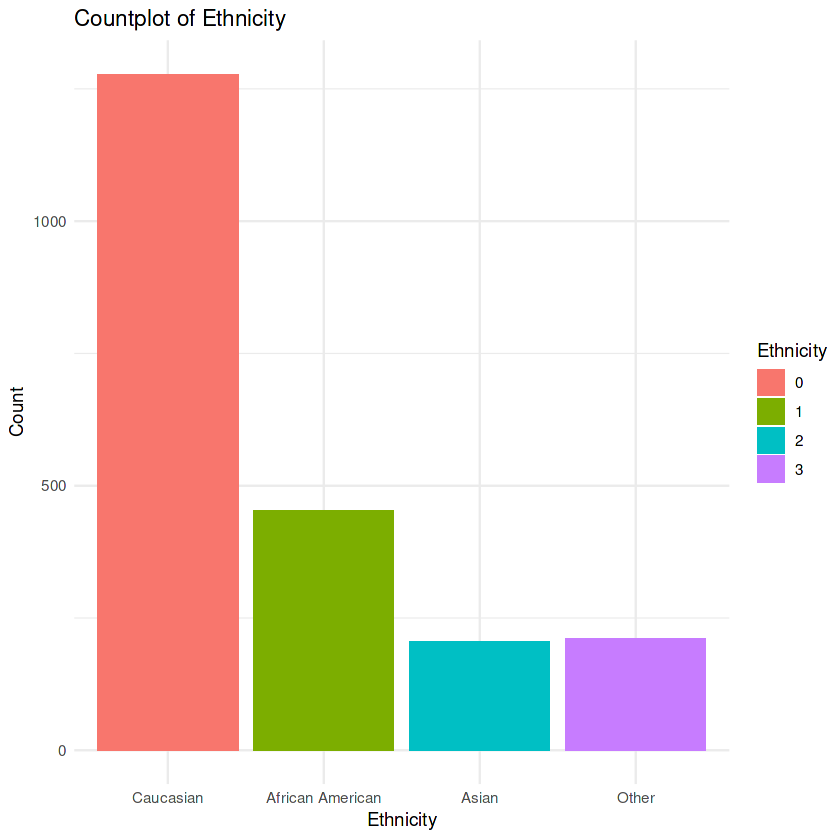

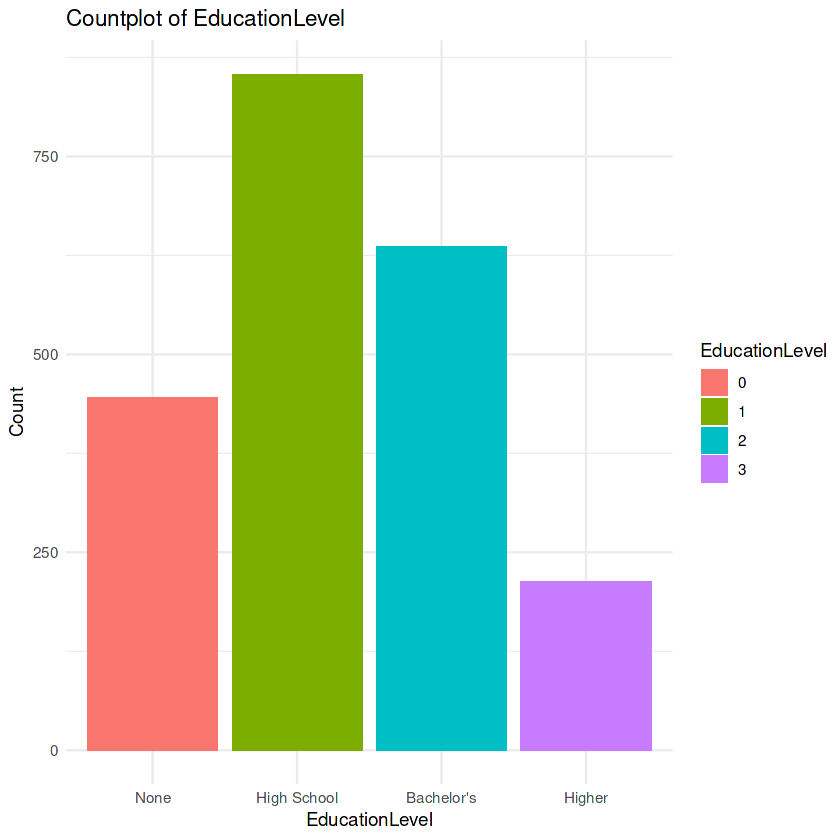

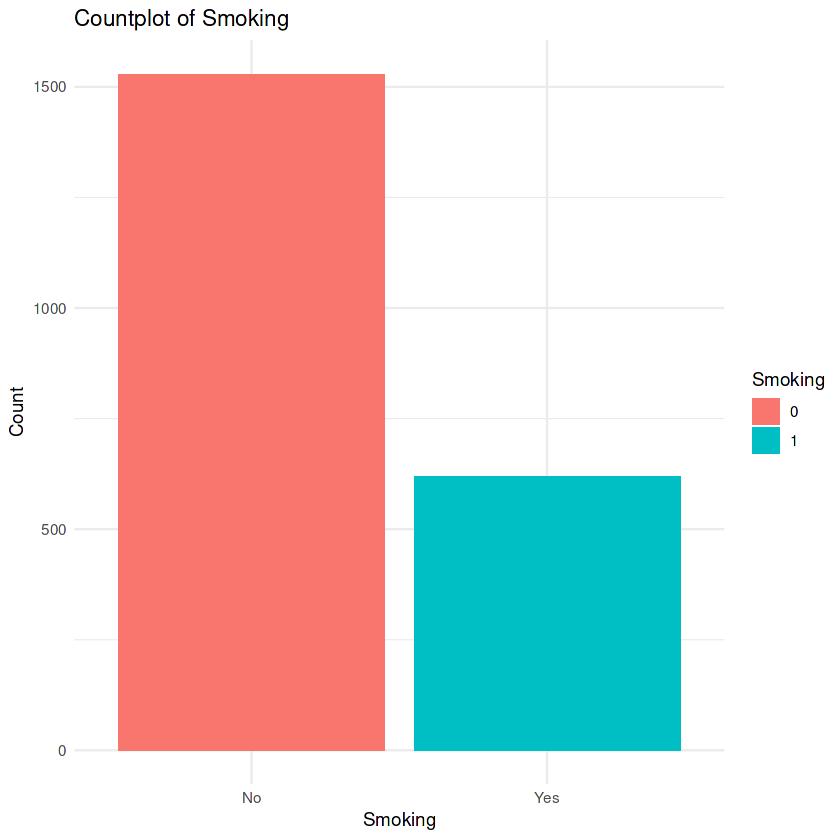

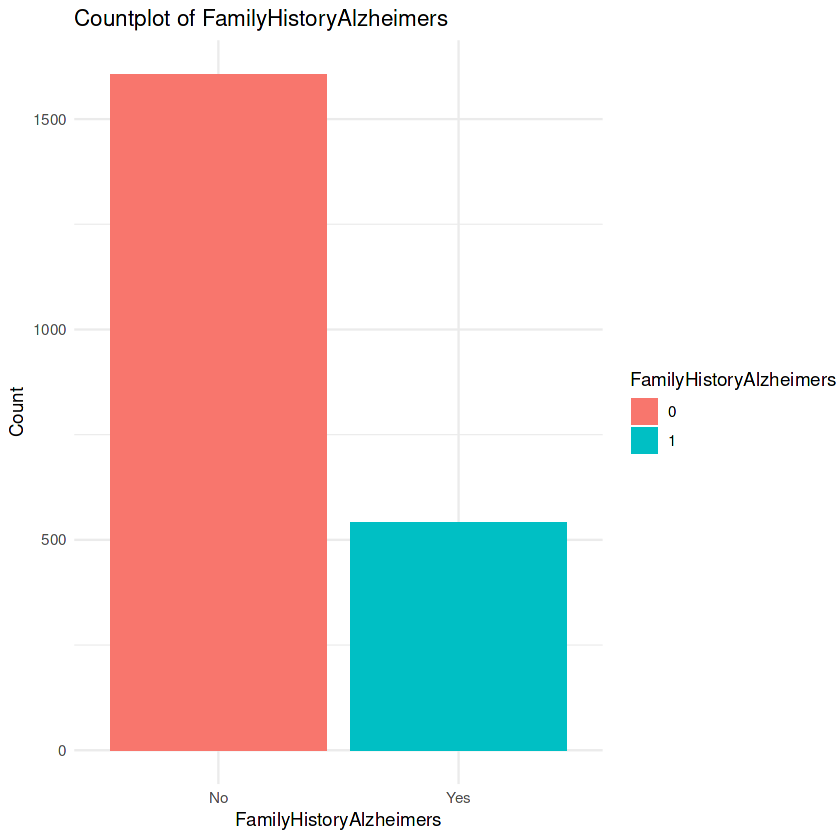

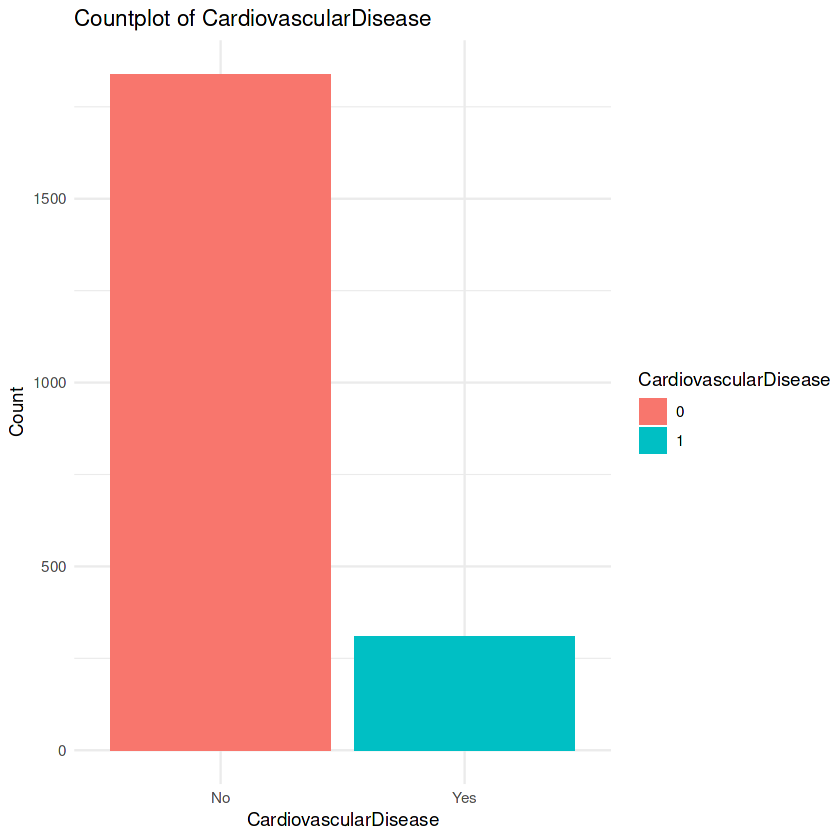

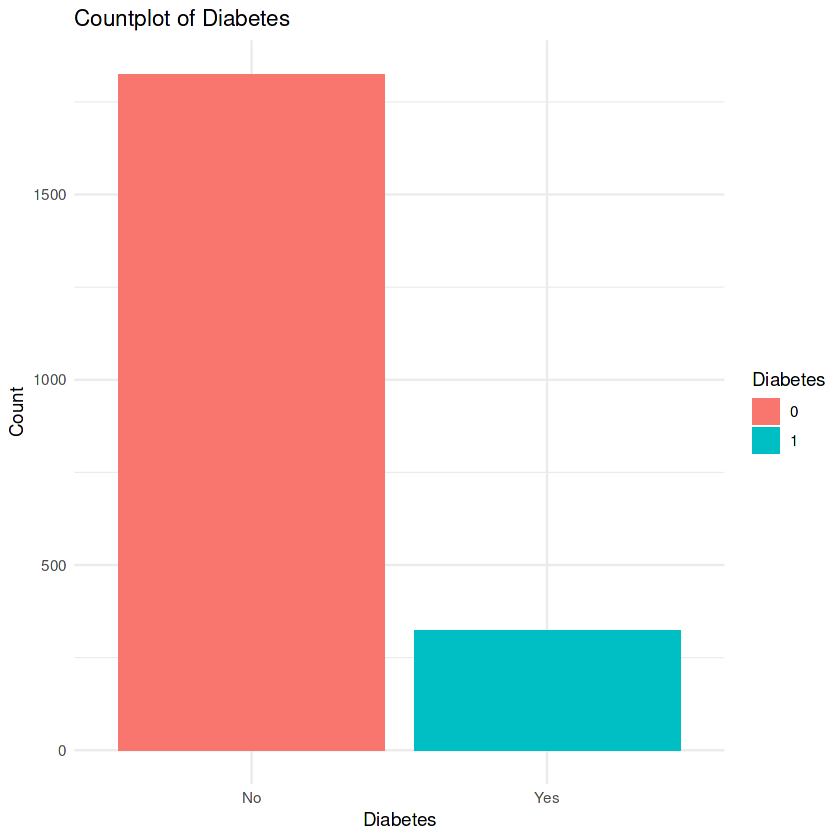

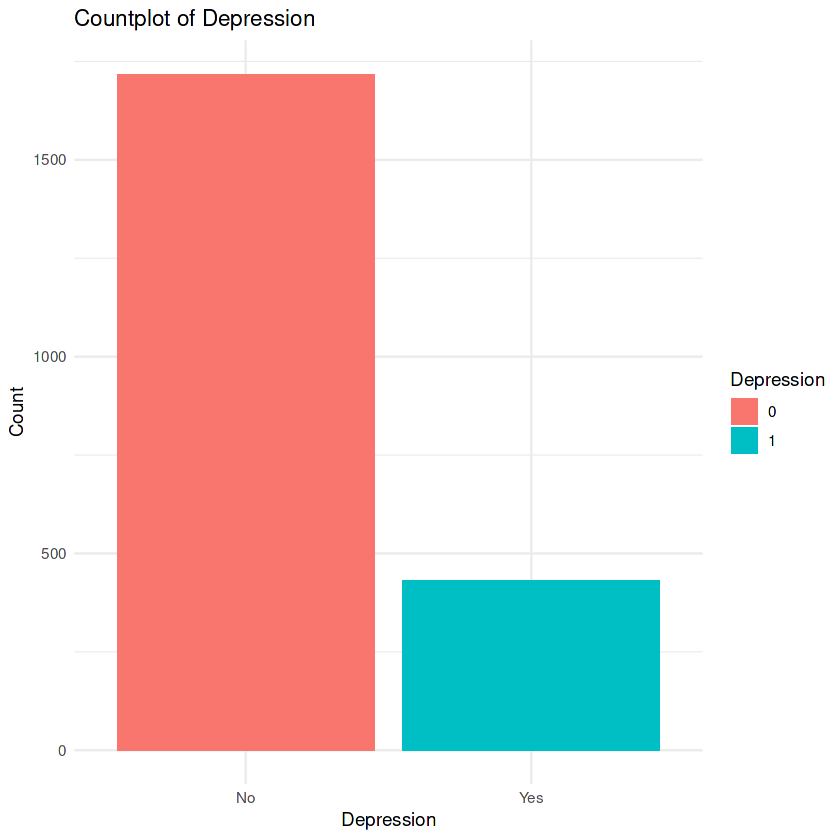

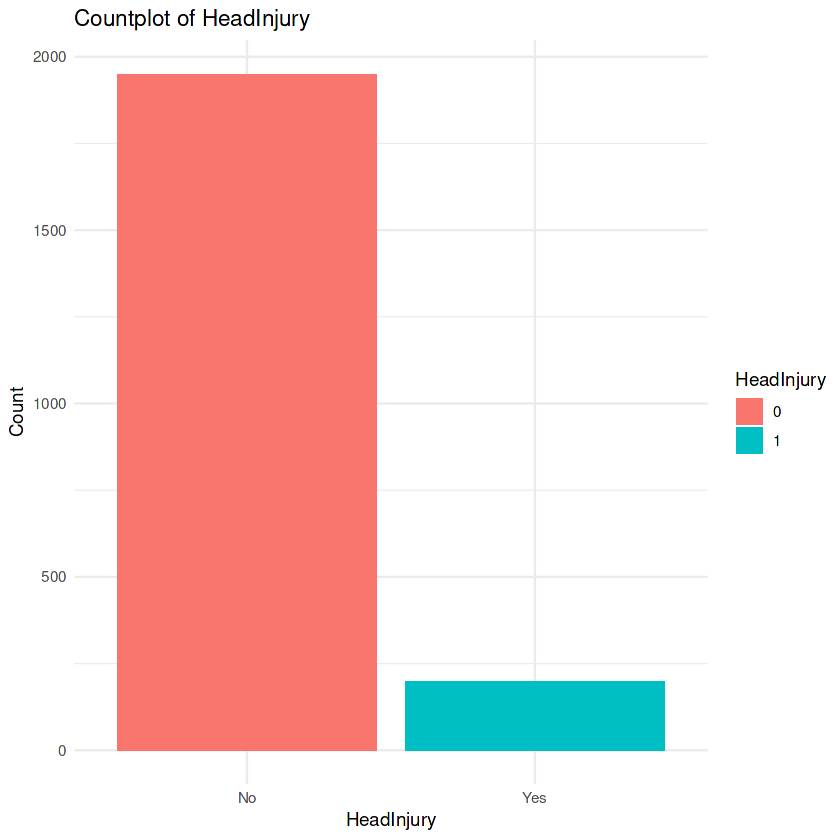

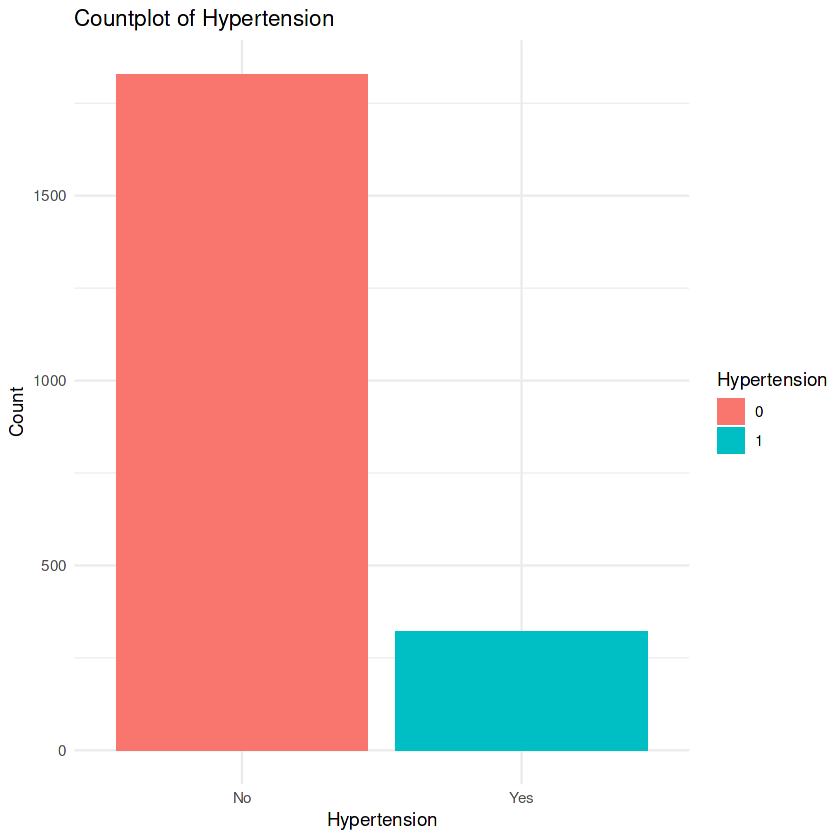

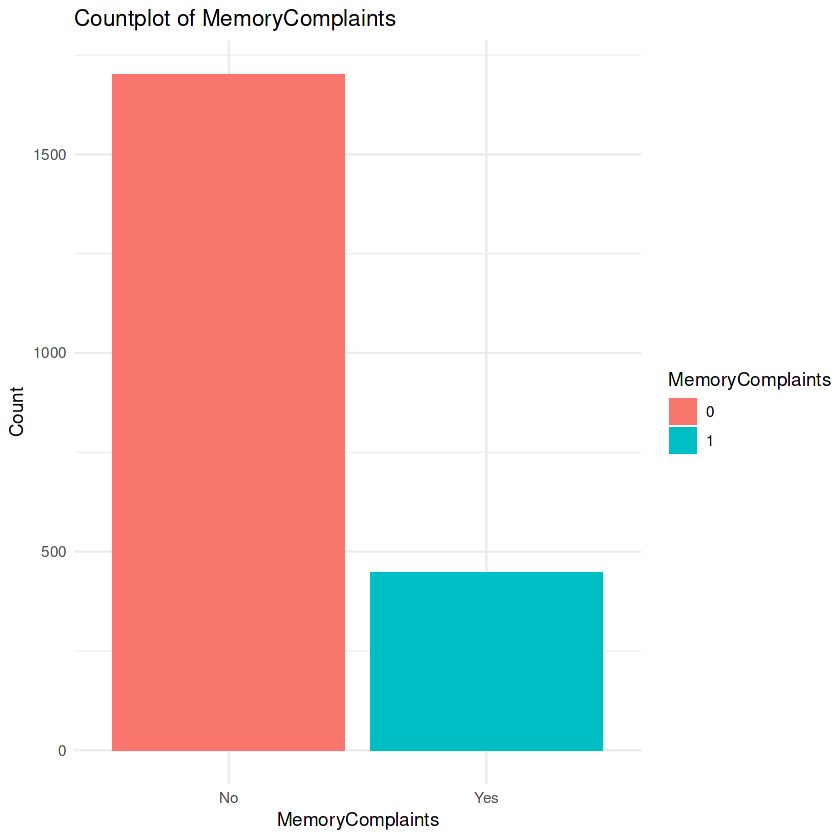

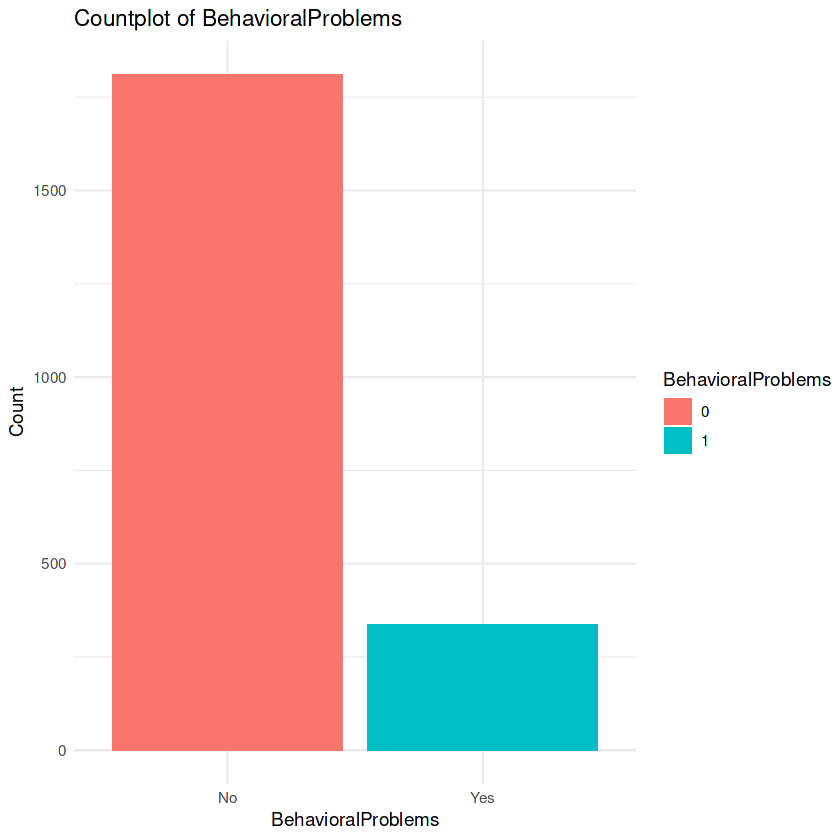

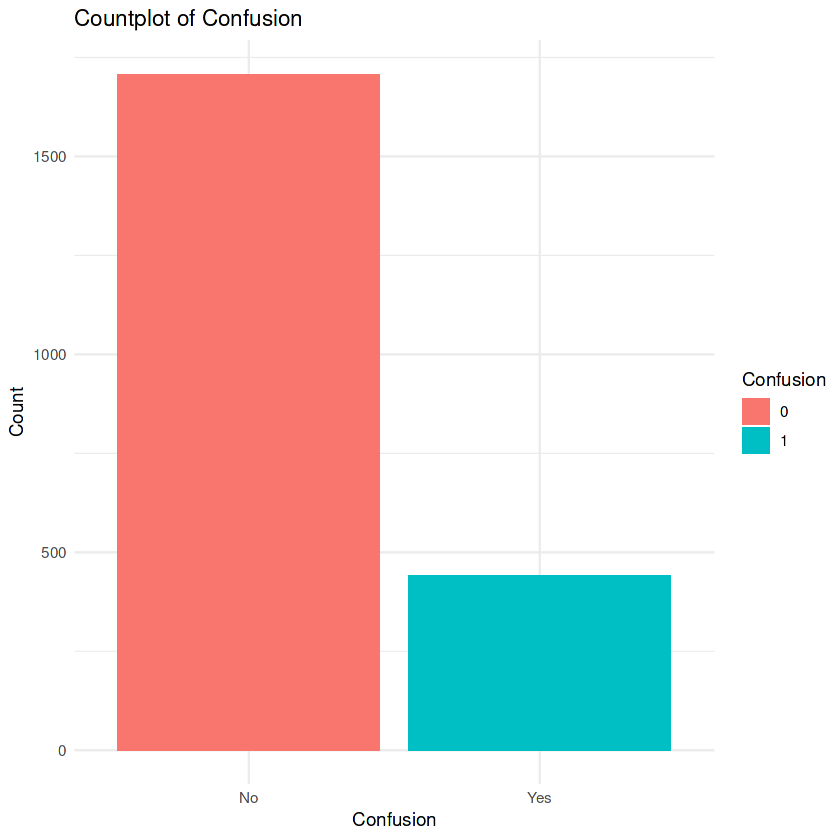

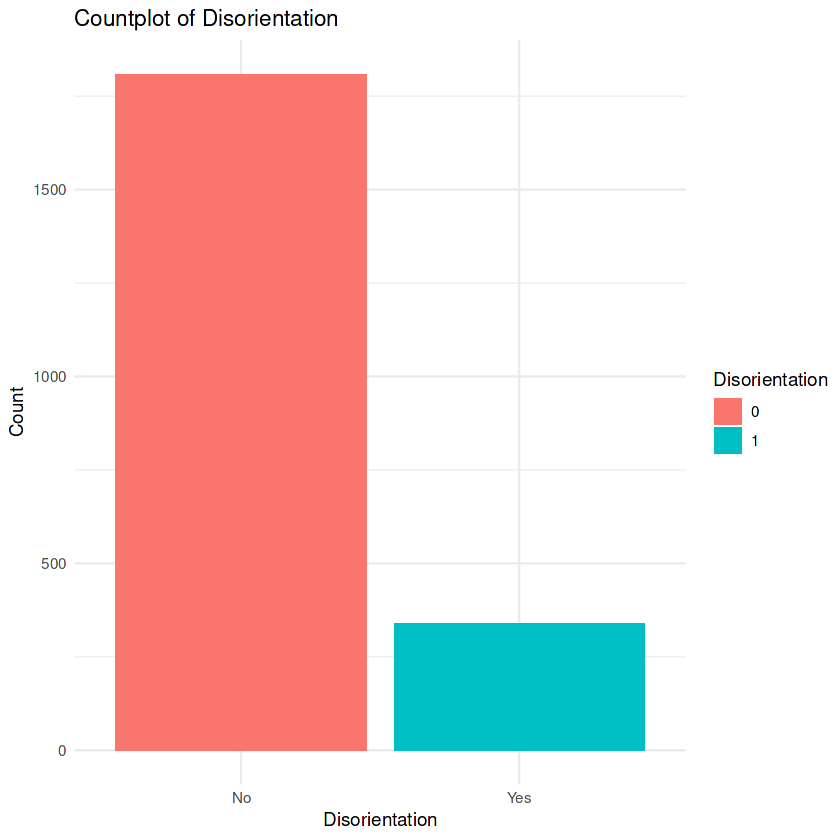

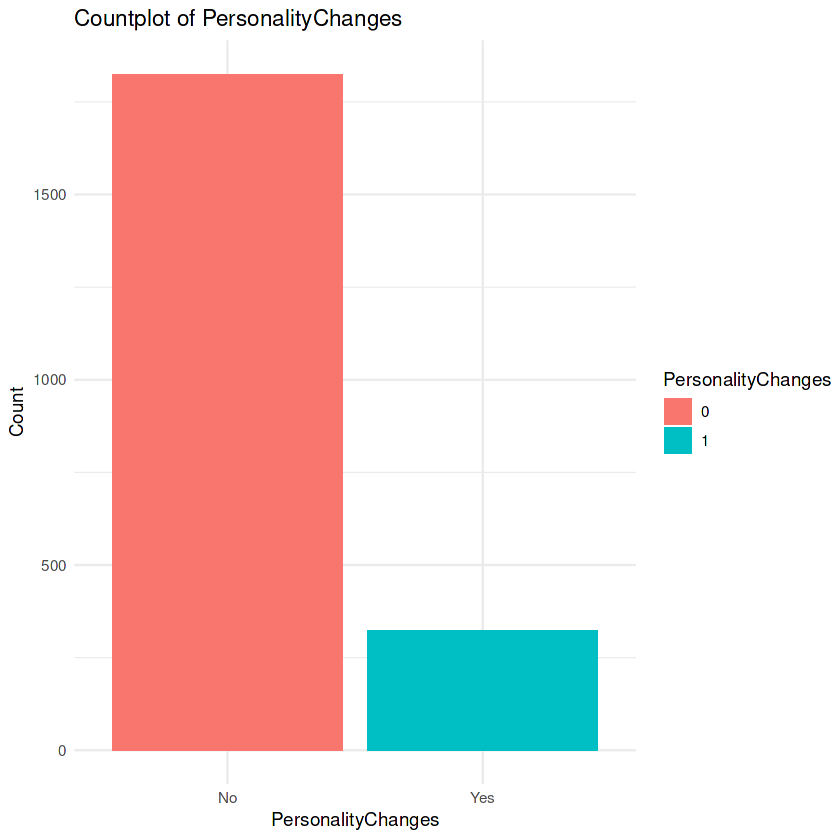

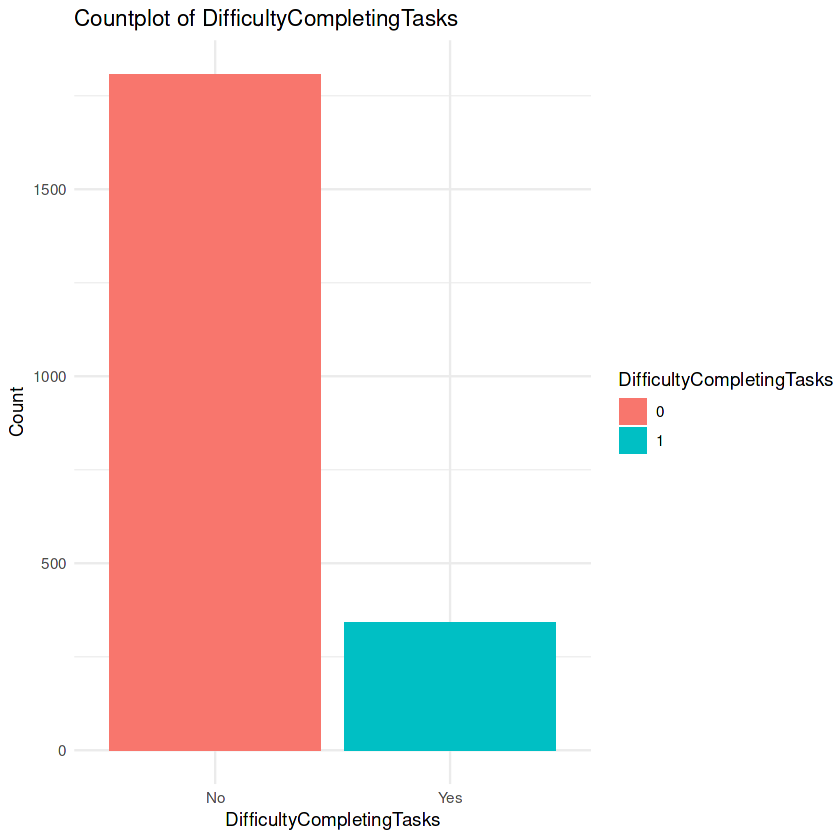

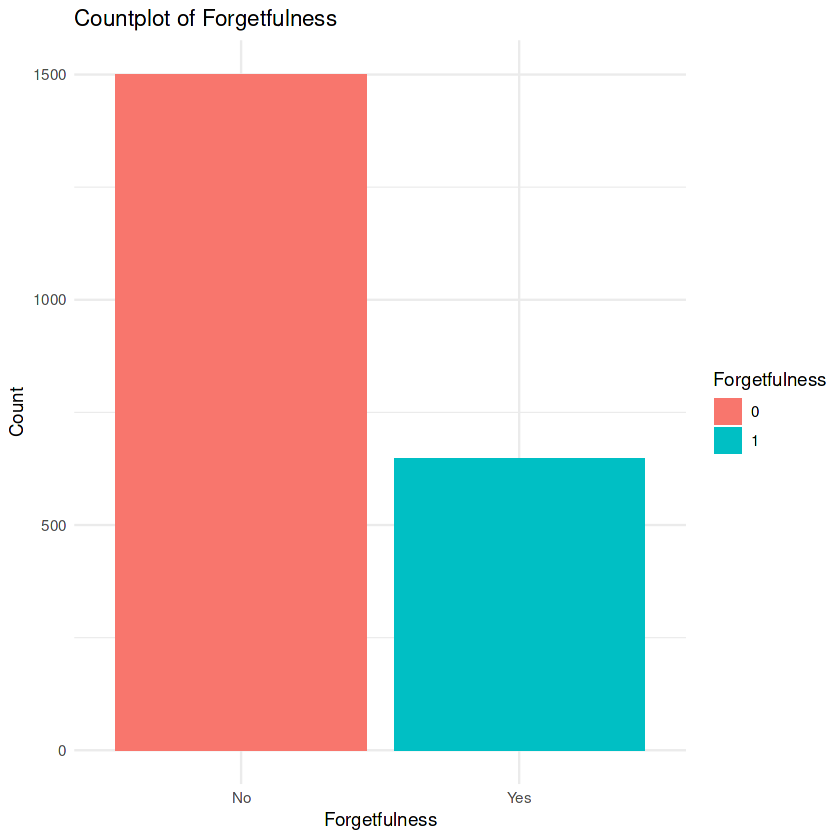

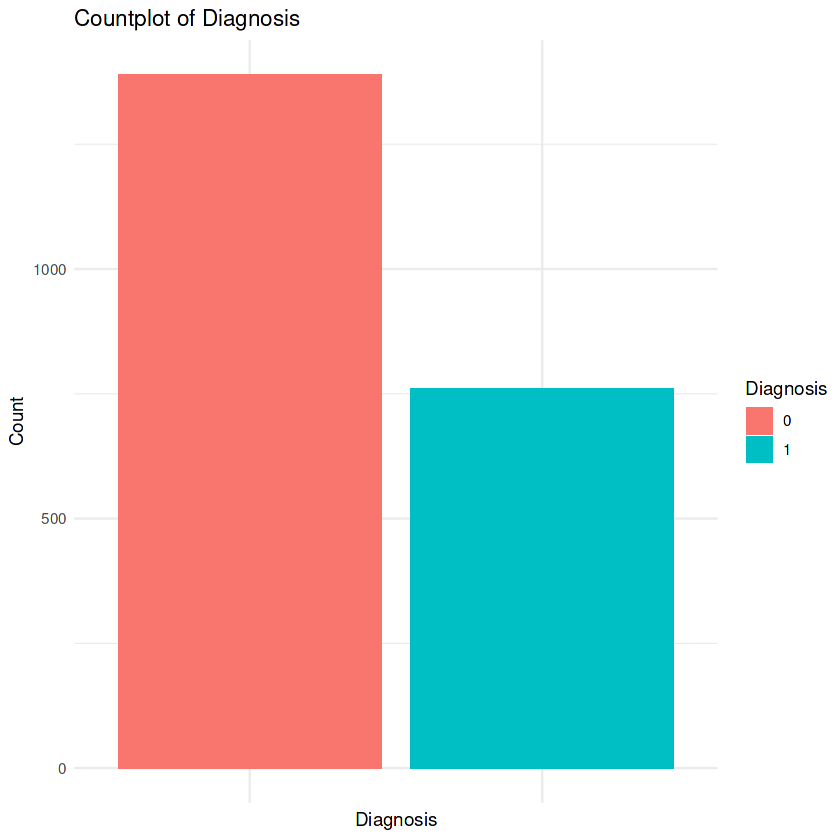

In [7]:
library(ggplot2)
library(dplyr)

# Define custom labels for categorical variables
custom_labels <- list(
  Gender = c("Male", "Female"),
  Ethnicity = c("Caucasian", "African American", "Asian", "Other"),
  EducationLevel = c("None", "High School", "Bachelor's", "Higher"),
  Smoking = c("No", "Yes"),
  FamilyHistoryAlzheimers = c("No", "Yes"),
  CardiovascularDisease = c("No", "Yes"),
  Diabetes = c("No", "Yes"),
  Depression = c("No", "Yes"),
  HeadInjury = c("No", "Yes"),
  Hypertension = c("No", "Yes"),
  MemoryComplaints = c("No", "Yes"),
  BehavioralProblems = c("No", "Yes"),
  Confusion = c("No", "Yes"),
  Disorientation = c("No", "Yes"),
  PersonalityChanges = c("No", "Yes"),
  DifficultyCompletingTasks = c("No", "Yes"),
  Forgetfulness = c("No", "Yes")
)

data_factor <- data_df

for (col in categorical_cols) {
  data_factor[[col]] <- as.factor(data_factor[[col]])  # Ensure categorical variables are factors
  print(
    ggplot(data_factor, aes(x = !!sym(col), fill = !!sym(col))) +
      geom_bar() +
      labs(title = paste("Countplot of", col), x = col, y = "Count") +
      scale_x_discrete(labels = function(x) custom_labels[[col]][as.numeric(x) + 1]) +
      theme_minimal()
  )
}
remove(data_factor)

------------------------------------------------------------------------

### Observations from Visualization of Categorical Features

-   Overall, the dataset predominantly consists of individuals without disease or health problems.
-   The most represented demographic is Caucasian.
-   High school graduates constitute the largest educational group, closely followed by individuals with a bachelor's degree.
-   Notably, both females and males are equally represented across the dataset.

------------------------------------------------------------------------

### Correlation Heatmap


Attaching package: ‘reshape2’




The following objects are masked from ‘package:data.table’:

    dcast, melt




The following object is masked from ‘package:tidyr’:

    smiths




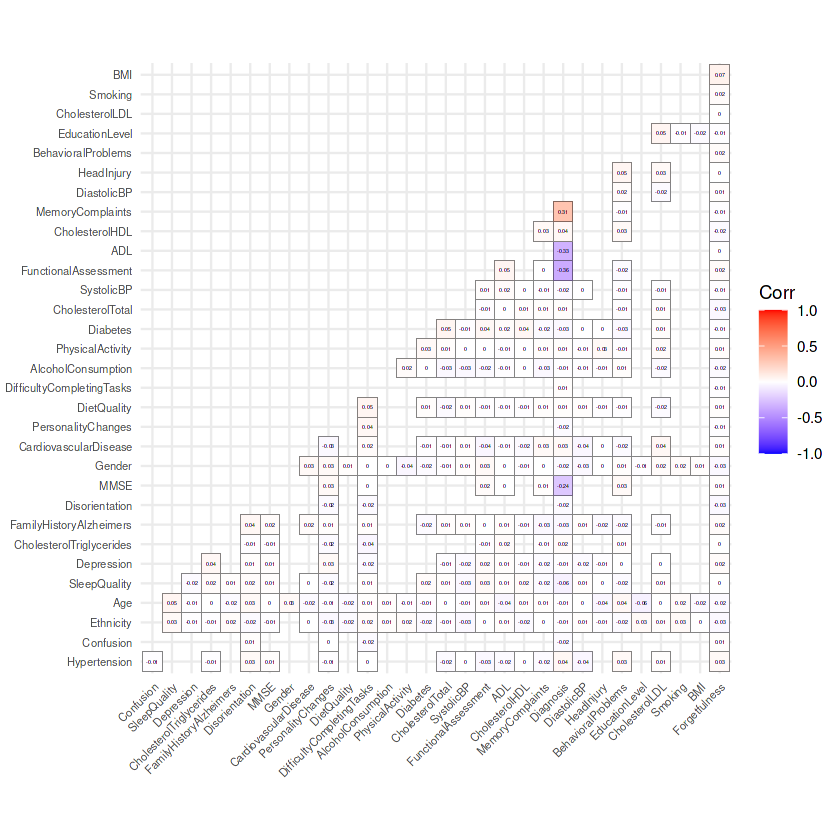

In [8]:
library(ggplot2)
library(reshape2)
library(ggcorrplot)

# Convert to a regular data.frame to avoid data.table issues
# data_df <- as.data.frame(data)

# Compute the correlation matrix
cor_matrix <- cor(data_df[, sapply(data_df, is.numeric)], use = "complete.obs")

# Mask upper triangle
cor_matrix[upper.tri(cor_matrix)] <- NA  

# Plot using ggcorrplot
library(ggcorrplot)
p <- ggcorrplot(cor_matrix, 
           hc.order = TRUE, 
           type = "lower", 
           lab = TRUE, 
           lab_size = 1,        # Reduce text size inside the heatmap
           tl.cex = 6.4,            # Reduce axis label size
           outline.color = "black", 
           ggtheme = theme_minimal()
           )

ggsave("correlation_plot.png", plot = p, width = 12, height = 10, dpi = 500)

print(p)

The heatmap reveals that the features do not have any strong correlations among themselves. However, there are five columns that show a correlation **with the target variable**.

Let's calculate Pearson correlation coefficient, also known as Pearson's r. It is a measure of the linear relationship between two variables. It quantifies the degree to which a pair of variables are linearly related, ranging from -1 to 1.

### Pearson Correlation Coefficient

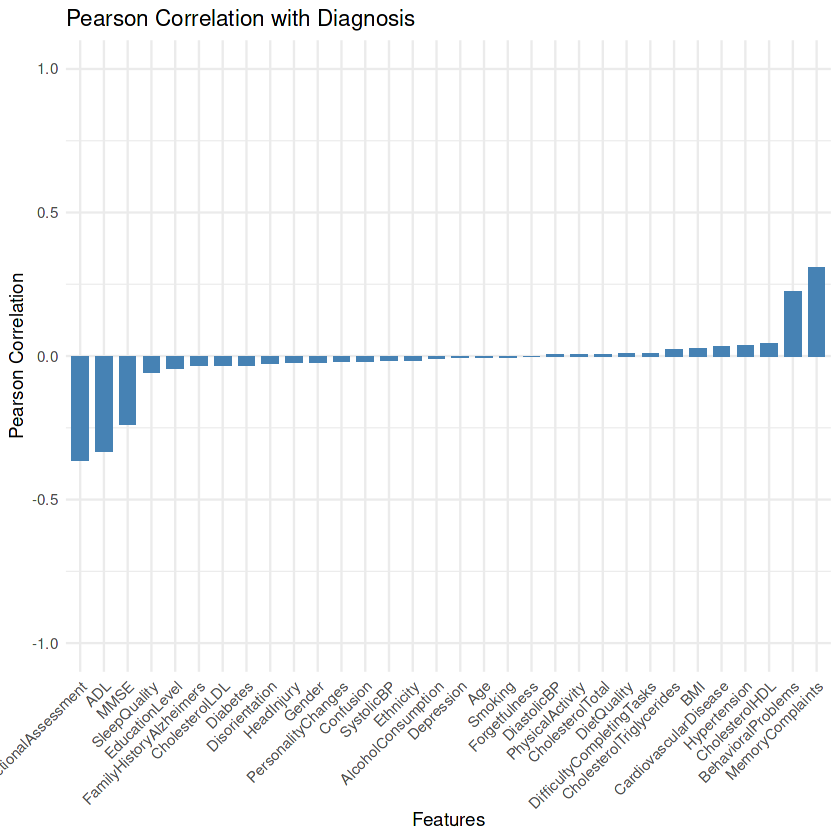

In [9]:
library(ggplot2)
library(dplyr)


# Compute Pearson correlation coefficients with "Diagnosis"
correlations <- cor(data_df[, sapply(data_df, is.numeric)], use = "complete.obs")["Diagnosis", ]

# Convert to dataframe for ggplot
cor_df <- data.frame(Feature = names(correlations), Correlation = correlations)

# Remove "Diagnosis" itself from the list
cor_df <- cor_df[cor_df$Feature != "Diagnosis", ]

# Sort by correlation values
cor_df <- arrange(cor_df, Correlation)

# Plot Pearson correlation bar chart
ggplot(cor_df, aes(x = reorder(Feature, Correlation), y = Correlation)) +
  geom_bar(stat = "identity", fill = "steelblue", width = 0.7) +  # Bar chart with custom width
  ylim(-1, 1) +  # Set y-axis limits
  labs(title = "Pearson Correlation with Diagnosis", 
       x = "Features", 
       y = "Pearson Correlation") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Rotate x-axis labels for readability

------------------------------------------------------------------------

### Observations from Exploring Correlations

-   As observed, there are five columns correlated with the target variable.
-   Three numerical features—`Functional Assessment`, `ADL` (Activities of Daily Living), and `MMSE` (Mini-Mental State Examination)—are negatively correlated with the `diagnosis of Alzheimer's disease`, with correlation coefficients of -0.36, -0.33, and -0.24 respectively. This indicates that lower scores in these assessments are associated with a higher likelihood of an Alzheimer's diagnosis.
-   Additionally, two categorical variables—`Behavioral Problems` and `Memory Complaints`—are positively correlated with the `diagnosis`, with correlation coefficients of 0.22 and 0.30 respectively. This means the presence of these issues is associated with a higher likelihood of an Alzheimer's diagnosis, highlighting their significance in the diagnostic process.

------------------------------------------------------------------------

### Normalize

In [10]:
normalize <- function(x) {
  return((x - min(x)) / (max(x) - min(x)))
}

columns <- c("Age", "BMI", "AlcoholConsumption", "PhysicalActivity", "DietQuality", 
             "SleepQuality", "SystolicBP", "DiastolicBP", "CholesterolTotal", 
             "CholesterolLDL", "CholesterolHDL", "CholesterolTriglycerides", 
             "MMSE", "FunctionalAssessment", "ADL")

data_df[columns] <- lapply(data_df[columns], normalize)

### Standardize

In [11]:
standardize <- function(x) {
  return((x - mean(x)) / sd(x))
}

data_df[columns] <- lapply(data_df[columns], standardize)
head(data_df)

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,⋯,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-0.212319,0,0,2,-0.6550728,0,0.5657914,0.4924103,-1.2533017,1.11965745,⋯,0.4973901,0,0,-1.1041775,0,0,0,1,0,0
2,1.567392,0,0,0,-0.1147243,0,-0.9546724,0.9448729,-1.5380839,0.05682309,⋯,0.7047429,0,0,-0.8104125,0,0,0,0,1,0
3,-0.212319,0,3,1,-1.3661100,0,1.6526209,1.0236577,-1.0886021,1.48703408,⋯,0.2817472,0,0,0.7243229,0,1,0,1,0,0
4,-0.101087,1,0,1,0.8514268,1,0.3768422,1.2277090,0.8396081,0.76065615,⋯,1.3430335,0,1,0.5079260,0,0,0,0,0,0
5,1.567392,0,0,0,-0.9613831,0,1.4614528,0.4865823,-1.4429567,-0.82437383,⋯,0.3335878,0,0,-1.6842869,0,0,1,1,0,0
6,1.233697,1,1,1,0.4116680,0,-1.0245554,-1.6481713,-1.1715887,0.11957058,⋯,0.1486786,0,0,1.3671308,1,0,0,0,0,0


## Modeling

### Test Train Split

In [12]:
library(dplyr)
library(caret)

set.seed(42)  # Ensure reproducibility

# Perform stratified sampling
trainIndex <- createDataPartition(data_df$Diagnosis, p = 0.8, list = FALSE)

# Create training and testing sets
train_data <- data_df[trainIndex, ]
test_data <- data_df[-trainIndex, ]

# Check dimensions
cat("Training Set Size:", nrow(train_data), "\n")
cat("Testing Set Size:", nrow(test_data), "\n")

Training Set Size: 1720 


Testing Set Size: 429 


#### Distribution of Training and Testing Set

In [13]:
# Check distribution in train and test sets
train_dist <- table(train_data$Diagnosis)
test_dist <- table(test_data$Diagnosis)

cat("\nTraining Set Distribution:\n")
print(train_dist)

cat("\nTesting Set Distribution:\n")
print(test_dist)

# Convert to proportions
train_prop <- prop.table(train_dist) * 100
test_prop <- prop.table(test_dist) * 100

cat("\nTraining Set Proportions (%):\n")
print(train_prop)

cat("\nTesting Set Proportions (%):\n")
print(test_prop)


Training Set Distribution:



   0    1 
1116  604 



Testing Set Distribution:



  0   1 
273 156 



Training Set Proportions (%):



       0        1 
64.88372 35.11628 



Testing Set Proportions (%):



       0        1 
63.63636 36.36364 


------------------------------------------------------------------------

### Observations from Data Splitting

The dataset is divided into training and testing sets while maintaining the class distribution.

-   The training set contains 1,116 samples of class 0 and 604 samples of class 1.
-   The testing set contains 273 samples of class 0 and 156 samples of class 1.
-   The class proportions in the training set are 64.88% (class 0) and 35.12% (class 1).
-   The class proportions in the testing set are 63.64% (class 0) and 36.36% (class 1).

------------------------------------------------------------------------

### Define Hyperparameter Grids For Each Model

In [14]:
param_grids <- list(
  "Decision Tree" = expand.grid(cp = c(0.01, 0.05, 0.1)),  # Complexity parameter for pruning
  "Random Forest" = expand.grid(mtry = c(3, 5, 7)),        # Number of features to consider at each split
  "K-Nearest Neighbors" = expand.grid(
    kmax = c(3, 5, 7),       # Number of neighbors to consider
    distance = c(1, 2),      # Distance metric (1=Euclidean, 2=Manhattan)
    kernel = c("rectangular", "triangular", "epanechnikov")  # Kernel types
  ),     
  "Logistic Regression" = NULL,                   # No hyperparameter tuning needed for base glm
  "Support Vector Machine" = expand.grid(C = c(0.1, 1, 10), sigma = c(0.1, 1)), 
  "XGBoost" = expand.grid(
    nrounds = c(50, 100, 200),            # Number of boosting iterations
    max_depth = c(3, 5, 7),               # Maximum depth of trees
    eta = c(0.01, 0.1, 0.3),              # Learning rate
    gamma = c(0),               # Minimum loss reduction
    colsample_bytree = c(0.5),    # Fraction of features to sample for each tree
    min_child_weight = c(3),         # Minimum sum of instance weight in a child
    subsample = c(0.5)            # Fraction of samples to use for each tree
  )
)

models <- list(
  "Decision Tree" = "rpart",
  "Random Forest" = "rf",
  "K-Nearest Neighbors" = "kknn",
  "Logistic Regression" = "glm",
  "Support Vector Machine" = "svmRadial",
  "XGBoost" = "xgbTree"
)


train_data$Diagnosis <- as.factor(train_data$Diagnosis)
test_data$Diagnosis <- as.factor(test_data$Diagnosis)

#### Train and Evaluate Models

In [15]:
results <- list()
for (name in names(models)) {
  
  # Perform cross-validation using caret's train function
  train_control <- trainControl(method = "cv", number = 5)
  
  model <- train(
    Diagnosis ~ .,  # Use the column name in train_data
    data = train_data,  # Use the full training dataset, not just x_train
    method = models[[name]],
    trControl = train_control,
    tuneGrid = param_grids[[name]],
    metric = "F1"
  )
  
  # Best model prediction
  y_pred <- predict(model, newdata = test_data)
  
  # Evaluate performance
  confusion <- confusionMatrix(y_pred, test_data$Diagnosis)
  # cat(name, "Classification Report:\n")
  # print(confusion)
  
  # Store results
  results[[name]] <- list("Best Model" = model, "Confusion Matrix" = confusion)
}

Warning message in train.default(x, y, weights = w, ...):
“The metric "F1" was not in the result set. Accuracy will be used instead.”


Warning message in train.default(x, y, weights = w, ...):
“The metric "F1" was not in the result set. Accuracy will be used instead.”


Warning message in train.default(x, y, weights = w, ...):
“The metric "F1" was not in the result set. Accuracy will be used instead.”


Warning message in train.default(x, y, weights = w, ...):
“The metric "F1" was not in the result set. Accuracy will be used instead.”


Warning message in train.default(x, y, weights = w, ...):
“The metric "F1" was not in the result set. Accuracy will be used instead.”


Warning message in train.default(x, y, weights = w, ...):
“The metric "F1" was not in the result set. Accuracy will be used instead.”


[11:17:34] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[11:17:34] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[11:17:34] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[11:17:34] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[11:17:35] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[11:17:35] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[11:17:35] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[11:17:35] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[11:17:35] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[11:17:35] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is dep

### Compare Models ROC Curve

Type 'citation("pROC")' for a citation.




Attaching package: ‘pROC’




The following objects are masked from ‘package:stats’:

    cov, smooth, var




[1] "Decision Tree"


[1] "Random Forest"
[1] "K-Nearest Neighbors"
[1] "Logistic Regression"
[1] "Support Vector Machine"
[1] "XGBoost"


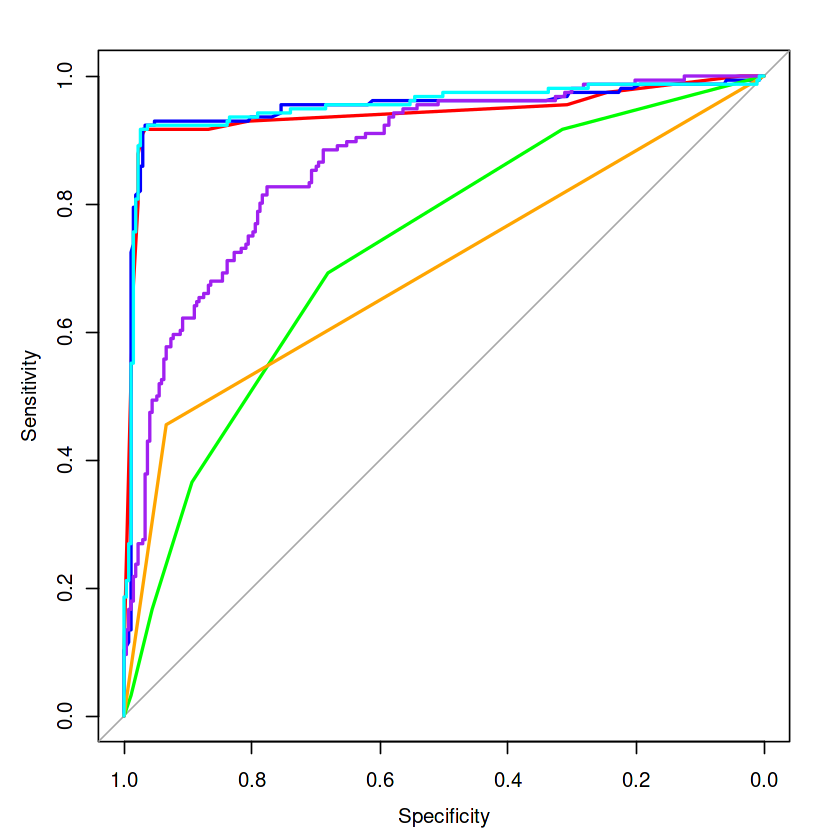

In [16]:
library(pROC)
colors <- c("red", "blue", "green", "purple", "orange", "cyan")
auc_values <- c()

i = 1

for (name in names(models)){
  print(name)
  if (name == "Support Vector Machine"){
    probs <- predict(results[[name]]$`Best Model`, newdata = test_data)
  }
  else{
    probs <- predict(results[[name]]$`Best Model`, newdata = test_data, type = "prob")[,2]
  }
  probs <- as.numeric(probs)
  
  roc_curve <- suppressMessages(roc(test_data$Diagnosis, probs, levels = c(0,1)))
  auc_value <- round(auc(roc_curve), 3)  # Get AUC and round it
  auc_values <- c(auc_values, auc_value)  # Store AUC for legend
  
  if (i == 1) {
    plot(roc_curve, col = colors[i], lwd = 2, add = FALSE)  # First model starts the plot
  } else {
    lines(roc_curve, col = colors[i], lwd = 2)  # Add to existing plot
  }
  # legend("bottomright", legend = paste("AUC =", round(auc(roc_curve), 2)), col = colors[i], lwd = 2)
  i = i + 1
}
# Create legend labels with AUC values
legend_labels <- paste(names(models), "(AUC =", auc_values, ")")

# Add legend with model names and AUC values
legend("bottomright", legend = legend_labels, col = colors, lwd = 2, cex = 0.6)

------------------------------------------------------------------------

### Observations from ROC Curve

The ROC curve evaluates the performance of different machine learning models in predicting Alzheimer's Disease. The AUC (Area Under the Curve) values indicate the discriminative ability of each model.

-   XGBoost (AUC = 0.959) achieved the highest AUC, indicating strong predictive performance.
-   Random Forest (AUC = 0.949) and Decision Tree (AUC = 0.941) also performed well, showing their effectiveness in classification.
-   Logistic Regression (AUC = 0.868) provided a good balance between complexity and interpretability.
-   K-Nearest Neighbors (AUC = 0.746) had moderate performance.
-   Support Vector Machine (AUC = 0.695) had the lowest AUC, suggesting limited effectiveness in this dataset.

Higher AUC values indicate better model performance, with XGBoost emerging as the best model for this prediction task.

------------------------------------------------------------------------

In [17]:
library(knitr)

# Extract and format the results
results_df <- data.frame(
  Model = names(results),
  Accuracy = sapply(results, function(x) x$`Confusion Matrix`$overall["Accuracy"]),
  Sensitivity = sapply(results, function(x) x$`Confusion Matrix`$byClass["Sensitivity"]),
  Specificity = sapply(results, function(x) x$`Confusion Matrix`$byClass["Specificity"]),
  F1_Score = sapply(results, function(x) x$`Confusion Matrix`$byClass["F1"])
)

# Round values for better readability
results_df <- results_df %>% mutate(across(-Model, round, 3))

# Print as a formatted table
kable(results_df, caption = "Model Performance Comparison")

# Print the formatted table
cat("\n### Model Performance Comparison\n")
print(kable(results_df, caption = "Performance Metrics"))

# Print confusion matrices for each model
cat("\n### Confusion Matrices:\n")
for (name in names(results)) {
  cat("\n**Model:", name, "**\n")
  print(results[[name]]$`Confusion Matrix`)
  cat("\n--------------------------------------------------\n")
}

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `across(-Model, round, 3)`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”




Table: Model Performance Comparison

|                                |Model                  | Accuracy| Sensitivity| Specificity| F1_Score|
|:-------------------------------|:----------------------|--------:|-----------:|-----------:|--------:|
|Decision Tree.Accuracy          |Decision Tree          |    0.949|       0.967|       0.917|    0.960|
|Random Forest.Accuracy          |Random Forest          |    0.951|       0.971|       0.917|    0.962|
|K-Nearest Neighbors.Accuracy    |K-Nearest Neighbors    |    0.702|       0.894|       0.365|    0.792|
|Logistic Regression.Accuracy    |Logistic Regression    |    0.795|       0.868|       0.667|    0.843|
|Support Vector Machine.Accuracy |Support Vector Machine |    0.760|       0.934|       0.455|    0.832|
|XGBoost.Accuracy                |XGBoost                |    0.946|       0.963|       0.917|    0.958|


### Model Performance Comparison




Table: Performance Metrics

|                                |Model                  | Accuracy| Sensitivity| Specificity| F1_Score|
|:-------------------------------|:----------------------|--------:|-----------:|-----------:|--------:|
|Decision Tree.Accuracy          |Decision Tree          |    0.949|       0.967|       0.917|    0.960|
|Random Forest.Accuracy          |Random Forest          |    0.951|       0.971|       0.917|    0.962|
|K-Nearest Neighbors.Accuracy    |K-Nearest Neighbors    |    0.702|       0.894|       0.365|    0.792|
|Logistic Regression.Accuracy    |Logistic Regression    |    0.795|       0.868|       0.667|    0.843|
|Support Vector Machine.Accuracy |Support Vector Machine |    0.760|       0.934|       0.455|    0.832|
|XGBoost.Accuracy                |XGBoost                |    0.946|       0.963|       0.917|    0.958|



### Confusion Matrices:



**Model: Decision Tree **
Confusion Matrix and Statistics

          Reference
Prediction   0   1
         0 264  13
         1   9 143
                                          
               Accuracy : 0.9487          
                 95% CI : (0.9234, 0.9676)
    No Information Rate : 0.6364          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.8886          
                                          
 Mcnemar's Test P-Value : 0.5224          
                                          
            Sensitivity : 0.9670          
            Specificity : 0.9167          
         Pos Pred Value : 0.9531          
         Neg Pred Value : 0.9408          
             Prevalence : 0.6364          
         Detection Rate : 0.6154          
   Detection Prevalence : 0.6457          
      Balanced Accuracy : 0.9418          
                                          
       'Positive' Class : 0               
   

------------------------------------------------------------------------

### Observations from Model Performance Comparison

Overall, XGBoost, Random Forest, and Decision Tree demonstrated the best predictive capability, with XGBoost achieving the highest sensitivity.

------------------------------------------------------------------------


In [18]:
print(results)

$`Decision Tree`
$`Decision Tree`$`Best Model`
CART 

1720 samples
  32 predictor
   2 classes: '0', '1' 

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 1376, 1376, 1375, 1377, 1376 
Resampling results across tuning parameters:

  cp    Accuracy   Kappa    
  0.01  0.9453554  0.8793855
  0.05  0.8680127  0.6919835
  0.10  0.8412887  0.6174316

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was cp = 0.01.

$`Decision Tree`$`Confusion Matrix`
Confusion Matrix and Statistics

          Reference
Prediction   0   1
         0 264  13
         1   9 143
                                          
               Accuracy : 0.9487          
                 95% CI : (0.9234, 0.9676)
    No Information Rate : 0.6364          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.8886          
                                          
 Mcnema